In [ ]:
%pip install scikit-learn numpy pandas

![ChatGPT Image 2026년 4월 22일 오전 11_26_09.png](<attachment:ChatGPT Image 2026년 4월 22일 오전 11_26_09.png>)
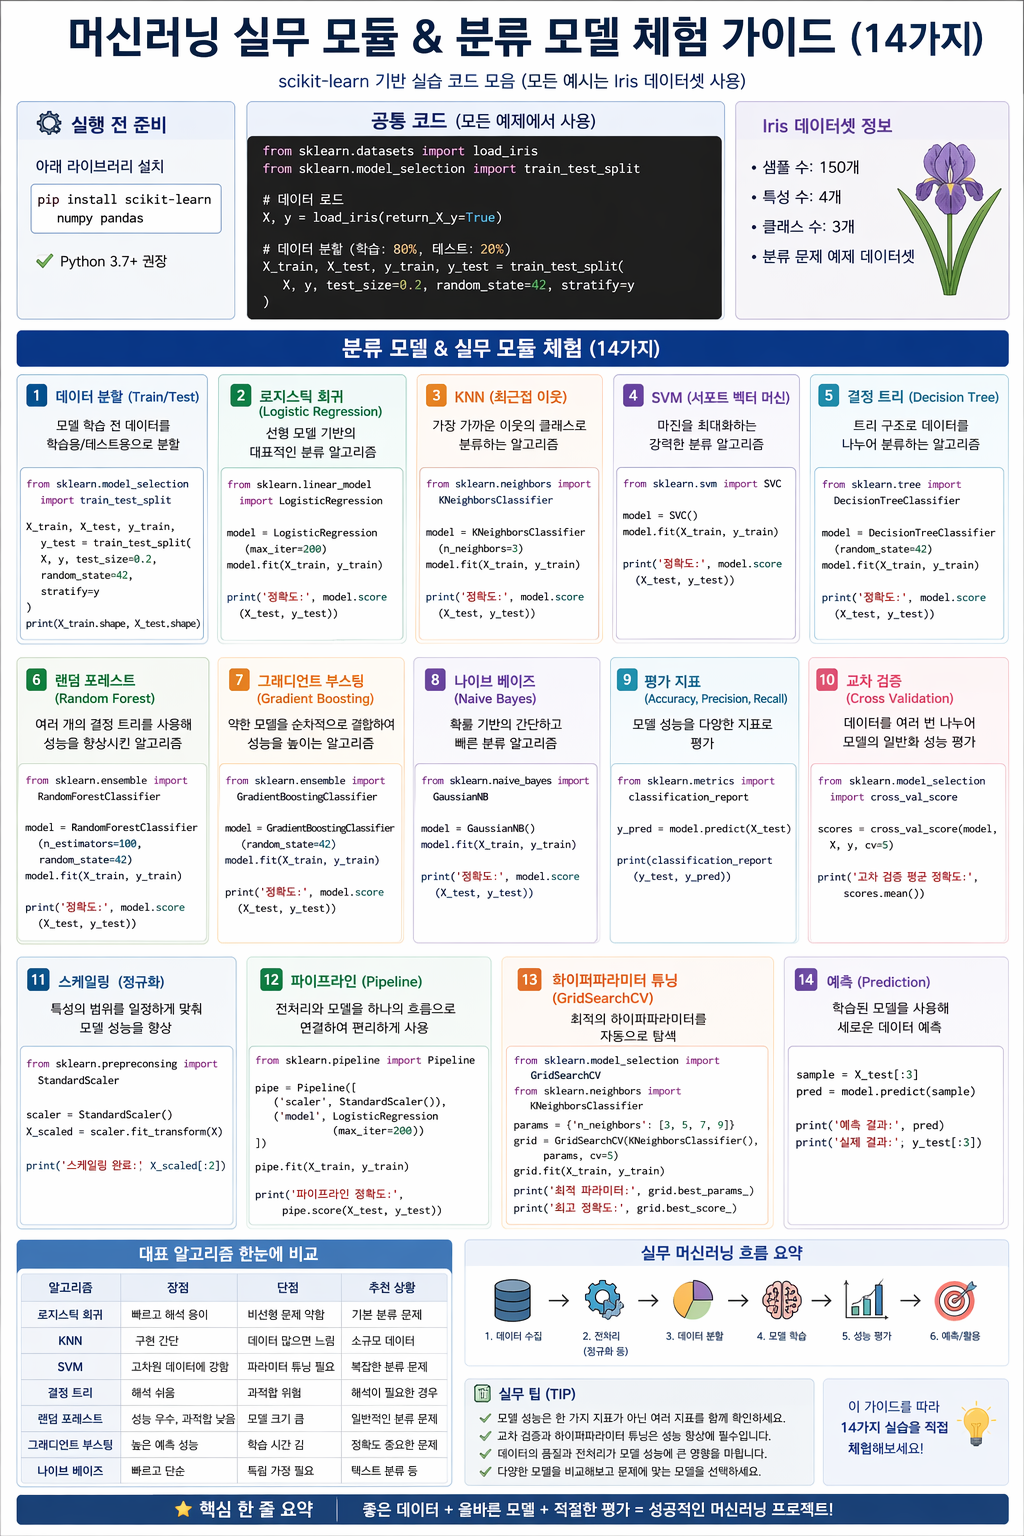

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">데이터 분할(train/test)</span>

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">로지스틱 회귀(Logistic Regression)</span>

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.9736842105263158


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">KNN(최근접 이웃)</span>

In [5]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

1.0


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">SVM(서포트 벡터 머신)</span>

In [6]:
from sklearn.svm import SVC

model = SVC()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.9736842105263158


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">결정 트리(Decision Tree)</span>

In [7]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.9736842105263158


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">랜덤 포레스트 (Random Forest)</span>

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.9736842105263158


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">그래디언트 부스팅 (Gradient Boosting)</span>


In [9]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.9736842105263158


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">나이브 베이즈 (Naive Bayes)</span>


In [10]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.9736842105263158


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">평가 지표 (Accuracy, Precision, Recall)</span>


In [11]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.94      0.97        16
           2       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">교차 검증 (Cross Validation)</span>


In [12]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(scores.mean())

0.9533333333333334


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">스케일링 (정규화)</span>



In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">파이프라인 (Pipeline)</span>


In [14]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipe.fit(X_train, y_train)
print(pipe.score(X_test, y_test))

0.9473684210526315


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">하이퍼파라미터 튜닝 (GridSearch)</span>


In [15]:
from sklearn.model_selection import GridSearchCV

params = {'n_neighbors': [3, 5, 7]}
grid = GridSearchCV(KNeighborsClassifier(), params)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'n_neighbors': 5}


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">예측 (Prediction)</span>


In [16]:
sample = X_test[:1]
print(model.predict(sample))

[2]


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">auto ML</span>

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 1.3em; font-style: italic;">최적의 알고리즘과 파라미터를 자동으로 찾아줌</span>



In [14]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 1. 데이터 로드 및 결측치 처리
df = sns.load_dataset('titanic').dropna(subset=['age', 'embarked'])
X = df[['pclass', 'age', 'sibsp', 'parch', 'fare']]
y = df['survived']

# 2. 비교할 모델 후보 리스트 (이게 AutoML의 원리입니다)
models = [
    ('Logistic', LogisticRegression()),
    ('RandomForest', RandomForestClassifier()),
    ('SVM', SVC())
]

# 3. 각 모델별 성적 테스트
print("--- 모델별 성능 비교 ---")
best_score = 0
best_model_name = ""

for name, model in models:
    # 교차 검증으로 평균 정확도 계산
    score = cross_val_score(model, X, y, cv=5).mean()
    print(f"{name}: {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_model_name = name

print(f"\n🏆 최종 선택된 모델: {best_model_name} (정확도: {best_score:.4f})")

--- 모델별 성능 비교 ---
Logistic: 0.6911
RandomForest: 0.6812
SVM: 0.6672

🏆 최종 선택된 모델: Logistic (정확도: 0.6911)
